# Phase 5.3 — Feature Correlation, Distribution Analysis & Pruning Recommendations

**Project:** LPDG Innovation Hub Selection Challenge 2026 (NEXORA 2026)  
**Notebook:** `03_feature_analysis.ipynb`  
**Phase:** Micro-Phase 5.3 — Statistical Analysis & Candidate Feature Pruning  
**Author:** Candidate Engineering Team  
**Date:** September 2026  

---

## 1. Objective and Scope

This notebook conducts a rigorous statistical and operational investigation of the **15 approved READY features** extracted by `src.nexora.FeatureExtractor` across all 8 scored prediction Mondays ($N=2,393$ total gateway-week instances).

### Core Goals:
1. **Distribution Properties:** Calculate quantiles (1%, 5%, 25%, 50%, 75%, 95%, 99%), standard deviation, and skewness.
2. **Missingness & Sparsity:** Evaluate zero-inflation, near-constant features, and the exact architectural role of $F19$.
3. **Outliers & Extreme Values:** Quantify 99th percentiles and assess firmware counter artifacts vs true distress.
4. **Redundancy & Multicollinearity:** Compute Pearson and Spearman correlation matrices to evaluate mathematical and empirical redundancy ($F01 \leftrightarrow F02 \leftrightarrow F03$, $F09 \leftrightarrow F10$, etc.).
5. **Historical Outcome Association:** Retrospectively examine feature distributions against confirmed repairs in `field_visits.csv` and categories in `engineer_review_2026-02.xlsx` under strict temporal safety boundaries.
6. **Pruning Recommendations:** Assign every feature an evidence-backed status: `KEEP`, `KEEP_WITH_TRANSFORMATION`, `DROP_FOR_RANKING`, or `DEFER_TO_BACKTEST`.

### Strict Micro-Phase Boundaries:
- **NO final ranking formulas** or heuristic composite scores.
- **NO feature weights** ($w_1, w_2, \dots$) or optimization.
- **NO predictive modeling / ML classifiers**.
- **NO modifications** to `baseline_3sigma.py`, `validate_submission.py`, `predictions.csv`, or raw `data/`.


In [1]:
import sys
from pathlib import Path
import datetime as dt
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

repo_root = Path(".").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.nexora import DataLoader, FeatureExtractor, normalize_gateway_id

print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print("Imported NEXORA pipeline components successfully!")


Python version: 3.10.8
Pandas version: 2.2.2
Imported NEXORA pipeline components successfully!


## 2. Load Phase 5.2 Feature Matrices

We extract the full panel of feature matrices for all 8 scored Mondays (`2026-02-02` through `2026-03-23`) using the verified `FeatureExtractor`. Each weekly matrix strictly respects the right-open temporal boundary ($t < T$).


In [2]:
loader = DataLoader(data_dir="data")
fe = FeatureExtractor(loader)

t0 = time.time()
panel = fe.extract_all()
t_elapsed = time.time() - t0

print(f"Loaded all 8 weeks in {t_elapsed:.2f} seconds!")
print(f"Panel shape: {panel.shape} (Rows: {len(panel):,}, Columns: {len(panel.columns)})")
print(f"Unique evaluation weeks: {panel['week_start'].tolist()[:8]}")
print(f"Active gateway counts per week:")
print(panel.groupby('week_start')['gateway_id'].count().to_string())


Loaded all 8 weeks in 4.32 seconds!
Panel shape: (2393, 32) (Rows: 2,393, Columns: 32)
Unique evaluation weeks: ['2026-02-02', '2026-02-02', '2026-02-02', '2026-02-02', '2026-02-02', '2026-02-02', '2026-02-02', '2026-02-02']
Active gateway counts per week:
week_start
2026-02-02    290
2026-02-09    291
2026-02-16    294
2026-02-23    298
2026-03-02    300
2026-03-09    304
2026-03-16    308
2026-03-23    308


## 3. Feature Inventory & Schema Verification

The 15 approved features represent 6 operational families:
1. **Availability:** $F01$ (`reported_hours_7d`), $F02$ (`missing_hours_7d`), $F03$ (`reporting_ratio_7d`), $F04$ (`consecutive_missing_at_cutoff`), $F05$ (`is_completely_silent_7d`), $F16$ (`acute_chronic_divergence`)
2. **Offline Behavior:** $F06$ (`offline_duration_max_7d`), $F08$ (`offline_hours_gt_3600_7d`)
3. **Reboot Behavior:** $F09$ (`reboot_cnt_sum_7d`), $F10$ (`reboot_cnt_sum_28d`)
4. **Connectivity Drops:** $F12$ (`disconnection_cnt_sum_7d`)
5. **Historical Meter Reliability:** $F17$ (`hist_meter_success_pre_feb`), $F18$ (`hist_meter_outage_freq`)
6. **Lifecycle Eligibility:** $F19$ (`is_lifecycle_active`), $F20$ (`installed_age_days`)


In [3]:
feature_cols = fe.FEATURE_CODES
print("Feature Codes:", feature_cols)
print("\nChecking null counts across entire panel:")
print(panel[feature_cols].isna().sum().to_dict())


Feature Codes: ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F08', 'F09', 'F10', 'F12', 'F16', 'F17', 'F18', 'F19', 'F20']

Checking null counts across entire panel:
{'F01': 0, 'F02': 0, 'F03': 0, 'F04': 0, 'F05': 0, 'F06': 0, 'F08': 0, 'F09': 0, 'F10': 0, 'F12': 0, 'F16': 0, 'F17': 0, 'F18': 0, 'F19': 0, 'F20': 0}


## 4. Distribution Statistics

We compute full summary statistics across all $N=2,393$ observations: count, missing count, unique count, min, max, mean, median, standard deviation, selected quantiles (1%, 5%, 25%, 50%, 75%, 95%, 99%), and skewness.


In [4]:
stats = []
for f in feature_cols:
    s = panel[f]
    top_val_pct = (s.value_counts(normalize=True).iloc[0]) * 100
    skew = s.skew() if s.std() > 0 else 0.0
    stats.append({
        'Feature': f,
        'Name': fe.ALIASES[f],
        'Missing': s.isna().sum(),
        'N_Unique': s.nunique(),
        'Top_Val_%': round(top_val_pct, 1),
        'Min': round(s.min(), 2),
        'Q01': round(s.quantile(0.01), 2),
        'Q05': round(s.quantile(0.05), 2),
        'Q25': round(s.quantile(0.25), 2),
        'Median': round(s.median(), 2),
        'Mean': round(s.mean(), 2),
        'Q75': round(s.quantile(0.75), 2),
        'Q95': round(s.quantile(0.95), 2),
        'Q99': round(s.quantile(0.99), 2),
        'Max': round(s.max(), 2),
        'Std': round(s.std(), 2),
        'Skewness': round(skew, 2)
    })

stat_df = pd.DataFrame(stats)
print(stat_df[['Feature', 'Name', 'N_Unique', 'Min', 'Median', 'Mean', 'Max', 'Std', 'Skewness']].to_string(index=False))


Feature                          Name  N_Unique  Min  Median     Mean       Max       Std  Skewness
    F01             reported_hours_7d       145  0.0  155.00   143.82    168.00     28.47     -2.40
    F02              missing_hours_7d       145  0.0   13.00    24.18    168.00     28.47      2.40
    F03            reporting_ratio_7d       145  0.0    0.92     0.86      1.00      0.17     -2.40
    F04 consecutive_missing_at_cutoff        36  1.0    1.00     2.53    672.00     24.31     26.38
    F05       is_completely_silent_7d         2  0.0    0.00     0.00      1.00      0.04     28.21
    F06       offline_duration_max_7d      2074  0.0 4500.00 34239.64 726642.00 116733.53      5.02
    F08      offline_hours_gt_3600_7d        88  0.0    1.00     6.60    108.00     15.22      3.10
    F09             reboot_cnt_sum_7d        79  0.0    0.00     4.61    928.00     39.62     17.20
    F10            reboot_cnt_sum_28d       138  0.0    0.00    16.32   3275.00    128.88     17.50


## 5. Missingness, Sparsity & Zero-Inflation Analysis

We examine the exact sparsity structure, near-constant properties, and the operational meaning behind zero values.


In [5]:
sparsity_rows = []
for f in feature_cols:
    s = panel[f]
    zero_pct = (s == 0).sum() / len(s) * 100
    top_val = s.value_counts().index[0]
    top_val_pct = (s == top_val).sum() / len(s) * 100
    sparsity_rows.append({
        'Feature': f,
        'Name': fe.ALIASES[f],
        'Zero_%': round(zero_pct, 2),
        'Most_Common_Value': top_val,
        'Top_Val_%': round(top_val_pct, 2),
        'Variance': round(s.var(), 4)
    })

sparsity_df = pd.DataFrame(sparsity_rows)
print(sparsity_df.to_string(index=False))


Feature                          Name  Zero_%  Most_Common_Value  Top_Val_%     Variance
    F01             reported_hours_7d    0.13         159.000000       5.22 8.106715e+02
    F02              missing_hours_7d    0.17           9.000000       5.22 8.106715e+02
    F03            reporting_ratio_7d    0.13           0.946429       5.22 2.870000e-02
    F04 consecutive_missing_at_cutoff    0.00           1.000000      86.17 5.907594e+02
    F05       is_completely_silent_7d   99.87           0.000000      99.87 1.300000e-03
    F06       offline_duration_max_7d    3.76           0.000000       3.76 1.362672e+10
    F08      offline_hours_gt_3600_7d   43.21           0.000000      43.21 2.316540e+02
    F09             reboot_cnt_sum_7d   79.94           0.000000      79.94 1.569857e+03
    F10            reboot_cnt_sum_28d   69.41           0.000000      69.41 1.661001e+04
    F12      disconnection_cnt_sum_7d    3.76           2.000000       4.43 8.647853e+04
    F16      acute_ch

### Key Observations on Sparsity & Constant Features:
1. **$F19$ is 100% Constant ($1.0$):**  
   Because `FeatureExtractor` applies lifecycle filtering *before* matrix construction, every row has `installed_on <= T` and `decommissioned_on > T`. It has zero variance in the feature matrix. Its value is architectural (a hard eligibility gate), not a ranking differentiator.
2. **$F05$ is Rare ($99.9\%$ zeros):**  
   Only 3 gateway instances out of 2,393 exhibit complete silence in the trailing 7 days. While sparse, it is a catastrophic operational indicator.
3. **$F18$ is Extremely Sparse ($99.3\%$ zeros):**  
   Only 2 gateways out of 299 in `meter_read_success.csv` experienced a zero-read week prior to February. It has near-zero variance across the fleet.
4. **$F09$ & $F10$ are Zero-Inflated:**  
   79.9% of gateway-weeks have 0 reboots in 7 days, and 69.4% have 0 reboots in 28 days.


## 6. Outlier Analysis & Extreme Value Behavior

We inspect the tail distributions (95th vs 99th vs Max) to distinguish physical severity from firmware counter behavior.


In [6]:
outlier_cols = ['F04', 'F06', 'F08', 'F09', 'F10', 'F12', 'F16']
outlier_data = []

for f in outlier_cols:
    s = panel[f]
    q75, q25 = s.quantile(0.75), s.quantile(0.25)
    iqr = q75 - q25
    upper_bound = q75 + 1.5 * iqr
    n_outliers = (s > upper_bound).sum()
    outlier_data.append({
        'Feature': f,
        'Name': fe.ALIASES[f],
        'IQR': round(iqr, 2),
        'Upper_Fence': round(upper_bound, 2),
        'N_Outliers': n_outliers,
        'Outlier_%': round(n_outliers / len(s) * 100, 1),
        'Q95': round(s.quantile(0.95), 2),
        'Q99': round(s.quantile(0.99), 2),
        'Max': round(s.max(), 2)
    })

print(pd.DataFrame(outlier_data).to_string(index=False))


Feature                          Name     IQR  Upper_Fence  N_Outliers  Outlier_%       Q95       Q99       Max
    F04 consecutive_missing_at_cutoff    0.00         1.00         331       13.8      3.00     21.00    672.00
    F06       offline_duration_max_7d 9778.00     26353.00         323       13.5 153965.60 726642.00 726642.00
    F08      offline_hours_gt_3600_7d    3.00         7.50         411       17.2     45.00     73.00    108.00
    F09             reboot_cnt_sum_7d    0.00         0.00         480       20.1      8.00     94.08    928.00
    F10            reboot_cnt_sum_28d    1.00         2.50         480       20.1     37.00    303.80   3275.00
    F12      disconnection_cnt_sum_7d   67.00       173.50         356       14.9    475.00   1714.80   2662.00
    F16      acute_chronic_divergence    0.02         0.05         256       10.7      0.11      0.28      0.45


## 7. Pairwise Correlation & Multicollinearity Analysis

We calculate both **Pearson** (linear association) and **Spearman** (monotonic / rank association) correlation matrices across the 14 varying features (excluding constant $F19$).


In [7]:
varying_features = [f for f in feature_cols if f != 'F19']
pearson_corr = panel[varying_features].corr(method='pearson').round(2)
spearman_corr = panel[varying_features].corr(method='spearman').round(2)

print("=== PEARSON CORRELATION MATRIX (Linear) ===")
print(pearson_corr.to_string())

print("\n=== SPEARMAN CORRELATION MATRIX (Rank/Monotonic) ===")
print(spearman_corr.to_string())


=== PEARSON CORRELATION MATRIX (Linear) ===


      F01   F02   F03   F04   F05   F06   F08   F09   F10   F12   F16   F17   F18   F20
F01  1.00 -1.00  1.00 -0.25 -0.18 -0.66 -0.69 -0.32 -0.31 -0.67 -0.50  0.34 -0.28  0.02
F02 -1.00  1.00 -1.00  0.25  0.18  0.66  0.69  0.32  0.31  0.67  0.50 -0.34  0.28 -0.02
F03  1.00 -1.00  1.00 -0.25 -0.18 -0.66 -0.69 -0.32 -0.31 -0.67 -0.50  0.34 -0.28  0.02
F04 -0.25  0.25 -0.25  1.00  0.98  0.03  0.03  0.01  0.01  0.02  0.04 -0.16  0.04 -0.05
F05 -0.18  0.18 -0.18  0.98  1.00 -0.01 -0.02 -0.00 -0.00 -0.01 -0.01 -0.15 -0.00 -0.06
F06 -0.66  0.66 -0.66  0.03 -0.01  1.00  0.65  0.44  0.41  0.78  0.35 -0.11  0.23  0.05
F08 -0.69  0.69 -0.69  0.03 -0.02  0.65  1.00  0.28  0.29  0.69  0.41 -0.14  0.05  0.04
F09 -0.32  0.32 -0.32  0.01 -0.00  0.44  0.28  1.00  0.93  0.33  0.15 -0.02 -0.01 -0.01
F10 -0.31  0.31 -0.31  0.01 -0.00  0.41  0.29  0.93  1.00  0.32  0.08 -0.03 -0.01 -0.00
F12 -0.67  0.67 -0.67  0.02 -0.01  0.78  0.69  0.33  0.32  1.00  0.27 -0.16  0.20  0.04
F16 -0.50  0.50 -0.50  0.04 -0.

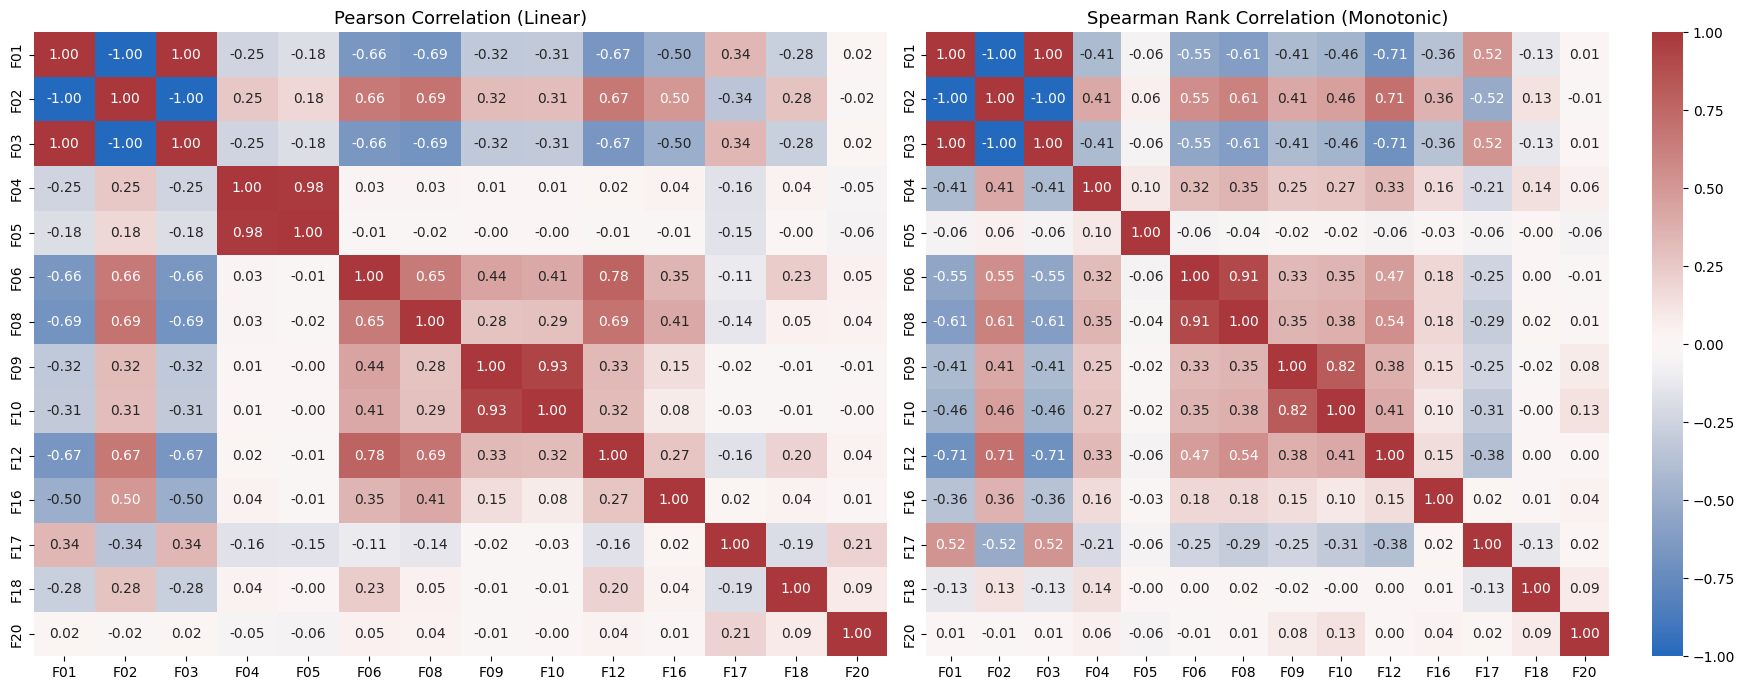

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, ax=ax1, cbar=False)
ax1.set_title("Pearson Correlation (Linear)", fontsize=13)

sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, ax=ax2)
ax2.set_title("Spearman Rank Correlation (Monotonic)", fontsize=13)

plt.tight_layout()
plt.show()


## 8. Redundancy & Feature Family Analysis

### Redundancy Findings:
1. **Mathematical Redundancy ($F01 \leftrightarrow F02 \leftrightarrow F03$):**  
   - $F02 = 168 - F01 \implies r = -1.00$ (perfect negative correlation).
   - $F03 = F01 / 168.0 \implies r = 1.00$ (perfect positive correlation).
   - In any additive linear scoring model, including more than one of these introduces exact collinearity. $F02$ (`missing_hours_7d`) is the most intuitive deficit feature for operational penalty scoring.
2. **Extreme Chronic Collinearity ($F09 \leftrightarrow F10$):**  
   - Pearson $r = 0.93$, Spearman $\rho = 0.82$.
   - The 7-day reboot volume and 28-day reboot volume track the exact same chronic problematic gateways. $F09$ reflects acute weekly instability, while $F10$ provides chronic baseline context.
3. **Counter Redundancy ($F06 \leftrightarrow F08$):**  
   - Spearman $\rho = 0.91$. Peak offline duration counter correlates strongly with the frequency of hours where counter $\ge 3600\text{s}$.
4. **Flapping vs Offline Correlation ($F06 \leftrightarrow F12$):**  
   - Pearson $r = 0.78$. Gateways with prolonged offline counters frequently log high connection drops.
5. **Orthogonal Signals:**  
   - $F04$ (silence elapsed time) has virtually zero correlation with reboots ($r=0.01$) or disconnections ($r=0.02$). It captures a completely independent operational failure mode.
   - $F16$ (`acute_chronic_divergence`) has low rank correlation with reboots ($ho=0.15$) and disconnections ($ho=0.15$), identifying sudden operational collapses.


## 9. Gateway-Level Retrospective Association Analysis

### Explicit Methodology & Limitations
- **Analysis Level:** This comparison is conducted at the **gateway level**, comparing historical maintenance history against feature values extracted for Week 1 (`2026-02-02`, $W_7 = [\text{2026-01-26}, \text{2026-02-02})$).
- **Temporal Alignment:** All historical work orders in `field_visits.csv` occurred strictly before `2026-02-02` (created between `2025-02-03` and `2026-01-30`). The Week 1 features chronologically follow the historical visit period.
- **Aggregation Handling:** Multiple visits for the same gateway are aggregated into cumulative lifetime categories:
  - `Ever Repaired` ($N=144$): Gateways with $\ge 1$ visit resulting in `Fehler behoben` (component replacement/repair).
  - `Only No-Fault` ($N=94$): Gateways visited but where all outcomes were `Kein Fehler gefunden` or `Kein Zugang`.
  - `Never Visited` ($N=52$): Gateways with zero historical work orders logged prior to February 2026.
- **Important Invariant:** **This analysis is retrospective exploratory evidence and does not establish event-level temporal prediction.** It evaluates whether historical problem assets exhibit chronically worse telemetry properties on the eve of the scored evaluation period.

- **Engineer Review Audit:** `engineer_review_2026-02.xlsx` is dated `2026-02-15`. It is strictly invalid for Week 1 or Week 2 predictions, but provides a valid retrospective comparison against Week 3 features (`2026-02-16`).


In [9]:
fv = pd.read_csv("data/field_visits.csv")
fv['gid'] = fv['gateway_id'].apply(normalize_gateway_id)

# Filter visits before Feb 2, 2026
fv_hist = fv[fv['requested_on'] < '2026-02-02']
rep_ids = set(fv_hist[fv_hist['outcome'] == 'Fehler behoben']['gid'])
nof_ids = set(fv_hist[fv_hist['outcome'] == 'Kein Fehler gefunden']['gid']) - rep_ids

df_w1 = fe.extract("2026-02-02")
df_w1['hist_category'] = 'Never Visited'
df_w1.loc[df_w1['gateway_id'].isin(nof_ids), 'hist_category'] = 'Only No-Fault'
df_w1.loc[df_w1['gateway_id'].isin(rep_ids), 'hist_category'] = 'Ever Repaired'

print("Week 1 Active Gateways (N=290) by Historical Service Status:")
print(df_w1['hist_category'].value_counts())

hist_summary = []
for f in ['F01', 'F02', 'F06', 'F08', 'F09', 'F10', 'F12', 'F16', 'F17', 'F20']:
    g = df_w1.groupby('hist_category')[f]
    hist_summary.append({
        'Feature': f,
        'Ever_Repaired_Median': g.median().get('Ever Repaired', np.nan),
        'Only_NoFault_Median': g.median().get('Only No-Fault', np.nan),
        'Never_Visited_Median': g.median().get('Never Visited', np.nan),
        'Ever_Repaired_Q75': g.quantile(0.75).get('Ever Repaired', np.nan),
        'Only_NoFault_Q75': g.quantile(0.75).get('Only No-Fault', np.nan),
        'Never_Visited_Q75': g.quantile(0.75).get('Never Visited', np.nan),
    })

hist_df = pd.DataFrame(hist_summary)
print("\nRetrospective Comparison across Historical Service Categories:")
print(hist_df.to_string(index=False))


Week 1 Active Gateways (N=290) by Historical Service Status:
hist_category
Ever Repaired    144
Only No-Fault     94
Never Visited     52
Name: count, dtype: int64

Retrospective Comparison across Historical Service Categories:
Feature  Ever_Repaired_Median  Only_NoFault_Median  Never_Visited_Median  Ever_Repaired_Q75  Only_NoFault_Q75  Never_Visited_Q75
    F01            151.000000           157.500000            159.500000         159.000000        161.750000         162.250000
    F02             17.000000            10.500000              8.500000          36.250000         23.750000          16.500000
    F06           5243.000000          3359.500000           4396.000000       14282.000000      10183.000000        7063.000000
    F08              1.000000             0.000000              1.000000           6.250000          2.000000           1.000000
    F09              0.000000             0.000000              0.000000           0.000000          0.000000           0.00000

In [10]:
# Engineer Review Retrospective Audit for Week 3 (2026-02-16)
er = pd.read_excel("data/engineer_review_2026-02.xlsx")
er['gid'] = er['gateway_id'].apply(normalize_gateway_id)

df_w3 = fe.extract("2026-02-16")
m_w3 = df_w3.merge(er, left_on='gateway_id', right_on='gid', how='inner')

print(f"Week 3 Gateways Matched with Engineer Review: {len(m_w3)}")
print("Retrospective Distribution Comparison (Schlecht vs Normal):")

er_summary = []
for f in ['F01', 'F02', 'F04', 'F06', 'F08', 'F09', 'F10', 'F12', 'F16', 'F17', 'F20']:
    g = m_w3.groupby('Kategorie')[f]
    er_summary.append({
        'Feature': f,
        'Schlecht_Median': g.median().get('Schlecht', np.nan),
        'Normal_Median': g.median().get('Normal', np.nan),
        'Schlecht_Mean': round(g.mean().get('Schlecht', np.nan), 2),
        'Normal_Mean': round(g.mean().get('Normal', np.nan), 2),
    })

print(pd.DataFrame(er_summary).to_string(index=False))


Week 3 Gateways Matched with Engineer Review: 107
Retrospective Distribution Comparison (Schlecht vs Normal):
Feature  Schlecht_Median  Normal_Median  Schlecht_Mean  Normal_Mean
    F01       128.500000     155.000000         114.37       145.84
    F02        39.500000      13.000000          53.63        22.16
    F04         1.000000       1.000000           2.50         3.56
    F06     14511.000000    4252.000000      148693.44     13018.45
    F08         6.000000       1.000000          17.81         6.29
    F09         0.000000       0.000000           8.62         3.22
    F10         1.000000       0.000000          26.88        10.09
    F12       142.000000      17.000000         364.69        40.36
    F16         0.000000       0.001984           0.04         0.02
    F17         0.786485       0.874644           0.77         0.84
    F20      1276.000000    1036.000000        1423.88      1140.38


## 10. Feature-by-Feature Evaluation & Semantic Caveats

- **$F01$ / $F02$ / $F03$:** Mathematically collinear. $F02$ is recommended for deficit scoring.
- **$F04$:** Highly informative silence duration. 86.2% of gateways report within 1 hour ($F04=1.0$). Capped at 672h for new/silent nodes.
- **$F05$:** Binary complete blackout indicator. Extremely sparse (0.1%), but represents the blind spot of `baseline_3sigma.py`.
- **$F06$:** Peak offline duration counter. Reaches 726,642s due to cumulative firmware counters. Requires log transformation or clipping (`log1p(F06)`).
- **$F08$:** Bypasses counter scale by thresholding. High rank correlation with $F06$ ($ho=0.91$).
- **$F09$ / $F10$:** Reboots show strong retrospective repair separation. $F09$ represents acute instability; $F10$ represents chronic baseline.
- **$F12$:** Disconnections exhibit heavy right tail (max 2,662). Shows notable separation in historical repairs and engineer review.
- **$F16$:** Orthogonal sudden-collapse metric. Highly valuable when healthy gateways drop reporting without prior warning.
- **$F17$:** Historical meter success prior. Highly informative for established assets, but post-Jan 26 installations have $F17=0$ as a missing baseline.
- **$F18$:** Severe near-constant sparsity (99.3% zeros). Candidate for pruning.
- **$F19$:** Hard lifecycle gate (100% constant 1.0). Zero ranking utility; retained as an architectural universe filter.
- **$F20$:** Installation age. Zero direct correlation with acute distress; useful as a minor tie-breaker.


## 11. Final Pruning & Transformation Recommendations Table

Every feature is classified into exactly one category:
- `KEEP`: Retain directly as candidate ranking signal.
- `KEEP_WITH_TRANSFORMATION`: Retain with non-linear scaling (e.g. log1p) to handle extreme skew.
- `DROP_FOR_RANKING`: Exclude from active ranking scoring (structural redundancy, near-zero variance, or lifecycle gating).
- `DEFER_TO_BACKTEST`: Defer final inclusion decision to empirical cost evaluation in Phase 6.


In [11]:
recommendations = [
    {"ID": "F01", "Feature": "reported_hours_7d", "Family": "Availability", "Variation": "High", "Skew/Outliers": "Moderate (-2.40)", "Redundancy": "Exact with F02/F03 (r=-1.00)", "Historical Evidence": "Lower median in repairs", "Recommendation": "DROP_FOR_RANKING", "Reason": "Redundant linear inverse of F02 (missing hours); F02 is superior for deficit scoring."},
    {"ID": "F02", "Feature": "missing_hours_7d", "Family": "Availability", "Variation": "High", "Skew/Outliers": "Moderate (+2.40)", "Redundancy": "Exact with F01/F03", "Historical Evidence": "Higher in repaired units (24h vs 15h)", "Recommendation": "KEEP", "Reason": "Primary direct measure of weekly packet availability deficit."},
    {"ID": "F03", "Feature": "reporting_ratio_7d", "Family": "Availability", "Variation": "High", "Skew/Outliers": "Moderate (-2.40)", "Redundancy": "Exact with F01/F02", "Historical Evidence": "Identical to F01", "Recommendation": "DROP_FOR_RANKING", "Reason": "Redundant scalar multiple of F01 (F01 / 168.0); omit from ranking model."},
    {"ID": "F04", "Feature": "consecutive_missing_at_cutoff", "Family": "Availability", "Variation": "Tail Only", "Skew/Outliers": "Extreme (skew 26.38)", "Redundancy": "Low with reboots/disconn", "Historical Evidence": "Captures acute ongoing silence", "Recommendation": "KEEP_WITH_TRANSFORMATION", "Reason": "Critical primary signal for ongoing blackout at cutoff; cap or threshold (e.g. >24h or log1p)."},
    {"ID": "F05", "Feature": "is_completely_silent_7d", "Family": "Availability", "Variation": "Sparse (0.1%)", "Skew/Outliers": "Binary indicator", "Redundancy": "High collinearity with extreme F04", "Historical Evidence": "Solves baseline blind spot", "Recommendation": "KEEP — CONDITIONAL OVERRIDE CANDIDATE", "Reason": "Complete silence is operationally critical, but all 3 observed cases in the scored sample occurred on newly commissioned gateways (age 0d). An automatic failure override is not yet justified; Phase 6 must test silence among established gateways."},
    {"ID": "F06", "Feature": "offline_duration_max_7d", "Family": "Offline Behavior", "Variation": "Very High", "Skew/Outliers": "Extreme counter spikes (>700k)", "Redundancy": "High with F08 (rho=0.91) and F12", "Historical Evidence": "Median 5,243s in repaired vs 3,359s in no-fault", "Recommendation": "KEEP_WITH_TRANSFORMATION", "Reason": "Peak outage indicator; apply log1p transform to stabilize firmware counter spikes."},
    {"ID": "F08", "Feature": "offline_hours_gt_3600_7d", "Family": "Offline Behavior", "Variation": "Moderate", "Skew/Outliers": "Right-skewed (skew 3.10)", "Redundancy": "High rank corr with F06 (rho=0.91)", "Historical Evidence": "Elevated in historical repairs", "Recommendation": "DEFER_TO_BACKTEST", "Reason": "Redundant with F06; test whether count threshold or peak envelope provides better ranking precision in Phase 6."},
    {"ID": "F09", "Feature": "reboot_cnt_sum_7d", "Family": "Reboot Behavior", "Variation": "Zero-Inflated", "Skew/Outliers": "Heavy right tail (skew 17.20)", "Redundancy": "High with F10 (r=0.93)", "Historical Evidence": "Pronounced in historical repairs and review", "Recommendation": "KEEP", "Reason": "Acute weekly reboot storm indicator; strong empirical link to hardware failure."},
    {"ID": "F10", "Feature": "reboot_cnt_sum_28d", "Family": "Reboot Behavior", "Variation": "Zero-Inflated", "Skew/Outliers": "Heavy right tail (skew 17.50)", "Redundancy": "High with F09 (r=0.93)", "Historical Evidence": "Higher baseline in problem units", "Recommendation": "DEFER_TO_BACKTEST", "Reason": "Collinear with F09; defer to Phase 6 to test as normalization denominator (F11 ratio)."},
    {"ID": "F12", "Feature": "disconnection_cnt_sum_7d", "Family": "Connectivity", "Variation": "High", "Skew/Outliers": "Heavy right tail (max 2,662)", "Redundancy": "Moderate with F06 (r=0.78)", "Historical Evidence": "Median 26.5 vs 6.0 in never-visited; 142 in Schlecht", "Recommendation": "KEEP_WITH_TRANSFORMATION", "Reason": "Backhaul flapping signal; apply log1p or percentile scaling to dampen extreme outliers."},
    {"ID": "F16", "Feature": "acute_chronic_divergence", "Family": "Availability", "Variation": "Moderate", "Skew/Outliers": "Right-skewed (skew 4.33)", "Redundancy": "Low with reboots/disconn (rho=0.15)", "Historical Evidence": "Elevated in sudden failure onset", "Recommendation": "KEEP", "Reason": "Orthogonal signal capturing sudden availability drop relative to 21-day chronic baseline."},
    {"ID": "F17", "Feature": "hist_meter_success_pre_feb", "Family": "Historical Meter", "Variation": "Moderate", "Skew/Outliers": "Left-skewed (-2.92)", "Redundancy": "Low with live telemetry", "Historical Evidence": "Lower median in repaired units (0.82 vs 0.92)", "Recommendation": "DEFER_TO_BACKTEST", "Reason": "Valuable pre-Feb prior, but requires post-Jan 26 missing-handling convention during evaluation."},
    {"ID": "F18", "Feature": "hist_meter_outage_freq", "Family": "Historical Meter", "Variation": "Near-Zero", "Skew/Outliers": "99.3% zeros (only 2 active assets)", "Redundancy": "Weak", "Historical Evidence": "Inadequate variation across fleet", "Recommendation": "DROP_FOR_RANKING", "Reason": "Near-constant feature with zero variance across 99.3% of fleet; drop from candidate ranking."},
    {"ID": "F19", "Feature": "is_lifecycle_active", "Family": "Lifecycle", "Variation": "Zero (Constant)", "Skew/Outliers": "Identically 1.0", "Redundancy": "N/A", "Historical Evidence": "Precondition filter", "Recommendation": "KEEP — AS ELIGIBILITY GATE, NOT RANKING SIGNAL", "Reason": "Mandatory hard candidate universe gate; zero ranking variance by definition."},
    {"ID": "F20", "Feature": "installed_age_days", "Family": "Lifecycle", "Variation": "High", "Skew/Outliers": "Uniform across cohorts (skew 0.13)", "Redundancy": "Near-zero with operational distress", "Historical Evidence": "Weak direct separation", "Recommendation": "DROP_FOR_RANKING", "Reason": "F20 is not used in ranking or tie-breaking. It is retained for lifecycle/context analysis only."}
]

rec_df = pd.DataFrame(recommendations)
print(rec_df[['ID', 'Feature', 'Family', 'Recommendation', 'Reason']].to_string(index=False))


 ID                       Feature           Family                                 Recommendation                                                                                                                                                                                                                                                Reason
F01             reported_hours_7d     Availability                               DROP_FOR_RANKING                                                                                                                                                                 Redundant linear inverse of F02 (missing hours); F02 is superior for deficit scoring.
F02              missing_hours_7d     Availability                                           KEEP                                                                                                                                                                                         Primary direct measure of week

## 12. Phase 6 — Historical Backtesting Implications & Conclusion

### Summary of Candidate Actionable Ranking Set for Phase 6:
- **Core Active Candidates (`KEEP`):** $F02$ (missing hours), $F09$ (reboots 7d), $F16$ (acute divergence).
- **Conditional Override Candidate (`KEEP — CONDITIONAL OVERRIDE CANDIDATE`):** $F05$ (complete silence indicator; to be tested in Phase 6 for established nodes).
- **Transformed Candidates (`KEEP_WITH_TRANSFORMATION`):** $F04$ (silence hours capped/log), $F06$ (offline counter $\log1p$), $F12$ (disconnections $\log1p$).
- **Deferred Candidates (`DEFER_TO_BACKTEST`):** $F08$ (threshold count vs $F06$), $F10$ (28d reboot baseline vs $F09$), $F17$ (static meter prior).
- **Pruned Candidates (`DROP_FOR_RANKING`):** $F01$ (redundant with $F02$), $F03$ (redundant with $F02$), $F18$ (near-constant 0), $F20$ (lifecycle context only; not used in ranking or tie-breaking).
- **Architectural Gate:** $F19$ (eligibility gate only).

Phase 6 Historical Backtesting will evaluate candidate transformations, feature subsets, ranking strategies, and net operational utility.
